<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/gradient_descent_part2_New_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent for Linear Regression. Part 2/2**
## **Learning Rate, Variantes y Optimización Práctica**

<a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>
<a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>
<a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

> **Esta es la Parte 2 de 2 de nuestra serie sobre Gradient Descent.**  
> En la [Parte 1](https://www.kaggle.com/code/magnitopic/gradient-descent-for-linear-regression-part-1-2) construimos el algoritmo desde cero y entendimos su funcionamiento intuitivo y matemático.  
> Ahora vamos a llevarlo al siguiente nivel: optimizarlo y usarlo como un profesional.

### ¿Qué aprenderemos hoy?

Si en la Parte 1 fuimos como un excursionista que baja la montaña paso a paso, aquí aprenderemos a **ajustar el tamaño de cada zancada** (learning rate), a **decidir cuántos compañeros consultar antes de movernos** (variantes del algoritmo) y a **evitar los errores más comunes**.

| Tema | Qué sabrás hacer al final |
|------|---------------------------|
| **Learning rate** | Elegir α adecuado y usar estrategias adaptativas |
| **Variantes** | Batch, SGD y Mini-Batch: cuándo usar cada una |
| **Validación profesional** | Comparar tu código con scikit-learn |
| **Checklist práctico** | Diagnosticar y solucionar problemas de convergencia |

¡Recuperemos nuestro dataset de precios de viviendas y empecemos!

---

# **1. Preparando los datos**

Usaremos el mismo dataset de la Parte 1 para mantener consistencia:

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset: área (m²) vs precio ($)
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

# Normalización de la feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1)).flatten()

# Matriz de diseño: columna de 1s + feature escalada
X_b = np.c_[np.ones(len(X_scaled)), X_scaled]

# Parámetros para desnormalizar después
mu, sigma = scaler.mean_[0], scaler.scale_[0]

print(f"✓ Dataset: {len(area)} ejemplos")
print(f"✓ Área: {area.min()}–{area.max()} m²")
print(f"✓ Precio: ${precio.min():,}–${precio.max():,}")

✓ Dataset: 10 ejemplos
✓ Área: 50–100 m²
✓ Precio: $140,000–$300,000


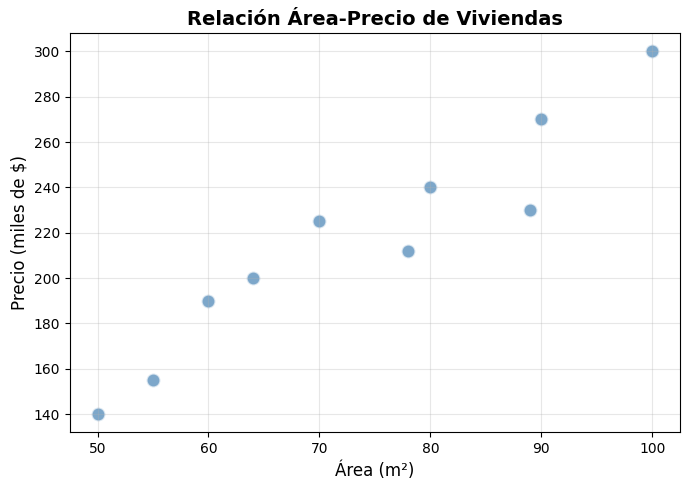

In [18]:
# Visualización rápida
plt.figure(figsize=(7, 5))
plt.scatter(area, precio/1000, s=100, alpha=0.7, color='steelblue',
            edgecolors='white', linewidth=1.5)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Relación Área-Precio de Viviendas', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

¡Datos listos! Ahora sí, vamos al grano: el hiperparámetro que más influye en el éxito o fracaso del algoritmo.

---

# **2. El Learning Rate: El Hiperparámetro Más Importante**

Recuerda la analogía del excursionista en la niebla: **el learning rate** $\alpha$ es el **tamaño de cada paso**.

- **Demasiado pequeño** → avanza muy lento (millones de pasos)
- **Demasiado grande** → zancadas gigantes, puede divergir
- **Adecuado** → llega rápido y estable al mínimo

En la práctica, $\alpha$ es el factor que más determina si el algoritmo converge bien o falla.

## **Función básica de Gradient Descent**

In [3]:
def gradient_descent(X_b, y, alpha=0.01, n_iter=2000, tol=1e-6):
    m = len(y)
    w = np.zeros(2)
    cost_history = []
    prev_cost = np.inf

    for i in range(n_iter):
        y_pred = X_b @ w
        error = y_pred - y
        gradient = (1/m) * X_b.T @ error
        w = w - alpha * gradient

        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

        if i > 0 and abs(prev_cost - cost) / prev_cost < tol:
            break
        prev_cost = cost

    return w, cost_history

## Experimentando con diferentes valores de α

In [4]:
alphas = [0.001, 0.01, 0.1, 1.0]
results = {}
histories = {}

for alpha in alphas:
    w, history = gradient_descent(X_b, precio, alpha=alpha)
    results[alpha] = len(history), history[-1]
    histories[alpha] = history

# Resultados
print("Resultados:")
print("α       | Iteraciones | Coste final")
print("--------|-------------|------------")
for alpha in alphas:
    iters, final_cost = results[alpha]
    print(f"{alpha:<7} | {iters:<11} | {final_cost:,.0f}")

Resultados:
α       | Iteraciones | Coste final
--------|-------------|------------
0.001   | 2000        | 551,788,495
0.01    | 765         | 106,201,768
0.1     | 86          | 106,196,965
1.0     | 3           | 106,196,560


**Observaciones típicas con este dataset normalizado:**

- **α = 0.001** → Muy lento (muchas iteraciones, aún no converge del todo).  
- **α = 0.01** → Buen equilibrio (converge en cientos de iteraciones).  
- **α = 0.1** → Rápido y estable.  
- **α = 1.0** → ¡Converge en muy pocas iteraciones! (en problemas simples puede funcionar).

**Cuidado:** En datasets reales más ruidosos o con múltiples features, α = 1.0 suele provocar divergencia (el coste explota). Por eso el rango seguro para empezar es **0.01–0.1**.

In [ ]:
# Visualización de la convergencia
plt.figure(figsize=(10, 5))
for alpha in alphas:
    plt.plot(histories[alpha], label=f'α = {alpha}')

plt.xlabel('Iteración')
plt.ylabel('Coste J(w)')
plt.title('Convergencia según el Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')  # Para ver mejor las diferencias
plt.show()

### Guía práctica para elegir α

| Síntoma                          | Diagnóstico                  | Acción recomendada                  |
|----------------------------------|------------------------------|-------------------------------------|
| Coste aumenta o explota          | α demasiado grande           | Dividir α por 10                    |
| Converge en < 100 iteraciones    | α óptimo o alto (estable)    | ¡Perfecto!                          |
| Converge en 100–2000 iteraciones | α aceptable                  | Bien, pero puedes probar mayor      |
| No converge tras > 5000 iter     | α demasiado pequeño          | Multiplicar α por 5–10              |
| Oscilaciones cerca del mínimo    | α un poco alto               | Reducir α un 20–30% o usar decay    |

**Regla de oro:** Empieza siempre con **α = 0.01**. Ajusta según la curva de coste.

### Bonus: Learning rate con decaimiento (adaptativo)

Una estrategia avanzada: empezar con α grande (exploración rápida) y reducirlo gradualmente (precisión final).

In [ ]:
def gradient_descent_decay(X_b, y, alpha_init=1.0, decay_rate=0.95, n_iter=2000):
    m = len(y)
    w = np.zeros(2)
    cost_history = []

    for i in range(n_iter):
        alpha = alpha_init * (decay_rate ** i)
        y_pred = X_b @ w
        error = y_pred - y
        gradient = (1/m) * X_b.T @ error
        w = w - alpha * gradient
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)
        if i > 1 and abs(cost_history[-2] - cost) / cost_history[-2] < 1e-6:
            break

    return w, cost_history

# Comparación
w_fixed, hist_fixed = gradient_descent(X_b, precio, alpha=0.01)
w_decay, hist_decay = gradient_descent_decay(X_b, precio, alpha_init=1.0, decay_rate=0.95)

plt.figure(figsize=(9, 5))
plt.plot(hist_fixed, label='α fijo = 0.01')
plt.plot(hist_decay, label='α con decaimiento (inicia en 1.0)')
plt.xlabel('Iteración')
plt.ylabel('Coste J(w)')
plt.title('Fijo vs Adaptativo')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

print(f"α fijo:      {len(hist_fixed)} iteraciones")
print(f"α decaimiento: {len(hist_decay)} iteraciones")

**Ventaja:** Combina velocidad inicial con refinamiento final. Muy útil en problemas más complejos.

¡Con esto ya dominas el learning rate!  
En la siguiente sección veremos las variantes del algoritmo (Batch, SGD y Mini-Batch) y cuándo usar cada una.

## **3. Las Variantes de Gradient Descent**

Hasta ahora hemos usado **Batch Gradient Descent**: en cada iteración calculamos el gradiente usando **todos los ejemplos** del dataset. Es estable y preciso, pero puede ser lento cuando hay miles o millones de datos.

Existen dos variantes principales que procesan los datos de forma diferente, ofreciendo un mejor equilibrio entre velocidad y estabilidad.

| Variante       | Datos por actualización | Ventajas principales                          | Desventajas                              | Cuándo usarla                              |
|----------------|------------------------|-----------------------------------------------|------------------------------------------|--------------------------------------------|
| **Batch GD**   | Todos (m ejemplos)     | Convergencia suave y precisa                  | Lento en datasets grandes                | Datasets pequeños o medianos (< 10k)       |
| **SGD**        | Un solo ejemplo        | Muy rápido por paso, escapa mínimos locales   | Convergencia ruidosa y oscilante         | Datasets enormes, aprendizaje online       |
| **Mini-Batch** | Grupo pequeño (ej. 32) | Equilibrio velocidad/estabilidad, estándar en DL | Requiere elegir tamaño de batch          | Casi siempre (la más usada en práctica)    |

Veamos las dos nuevas en código.

In [7]:
import numpy as np

# SGD: Stochastic Gradient Descent
def stochastic_gd(X_b, y, alpha=0.01, n_epochs=100):
    m = len(y)
    w = np.zeros(2)
    cost_history = []

    for epoch in range(n_epochs):
        # Mezclamos los índices al inicio de cada época
        indices = np.random.permutation(m)

        for i in indices:
            # Usamos un solo ejemplo
            xi = X_b[i:i+1]      # Mantener dimensión (1, 2)
            yi = y[i:i+1]

            y_pred = xi @ w
            error = y_pred - yi
            gradient = xi.T @ error          # Sin dividir por m (m=1)
            w = w - alpha * gradient

        # Guardamos coste al final de la época
        full_pred = X_b @ w
        cost = (1/(2*m)) * np.sum((full_pred - y)**2)
        cost_history.append(cost)

    return w, cost_history

In [8]:
# Mini-Batch Gradient Descent
def minibatch_gd(X_b, y, alpha=0.01, batch_size=4, n_epochs=200):
    m = len(y)
    w = np.zeros(2)
    cost_history = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_b[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            y_pred = xi @ w
            error = y_pred - yi
            gradient = (1/len(xi)) * xi.T @ error
            w = w - alpha * gradient

        # Coste sobre todo el dataset
        full_pred = X_b @ w
        cost = (1/(2*m)) * np.sum((full_pred - y)**2)
        cost_history.append(cost)

    return w, cost_history

### Comparación práctica

In [9]:
# Entrenamos las tres versiones
w_batch, hist_batch = gradient_descent(X_b, precio, alpha=0.01, n_iter=2000)
w_sgd,   hist_sgd   = stochastic_gd(X_b, precio, alpha=0.01, n_epochs=200)
w_mb,    hist_mb    = minibatch_gd(X_b, precio, alpha=0.01, batch_size=4, n_epochs=200)

# Desnormalizamos para mostrar el modelo final
def desnormalizar(w, mu, sigma):
    w1 = w[1] / sigma
    w0 = w[0] - w1 * mu
    return w0, w1

print("Modelos finales (Precio ≈ w0 + w1 × Área):")
print(f"Batch GD     → ${desnormalizar(w_batch, mu, sigma)[0]:,.0f} + ${desnormalizar(w_batch, mu, sigma)[1]:,.0f} × Área")
print(f"SGD          → ${desnormalizar(w_sgd, mu, sigma)[0]:,.0f} + ${desnormalizar(w_sgd, mu, sigma)[1]:,.0f} × Área")
print(f"Mini-Batch   → ${desnormalizar(w_mb, mu, sigma)[0]:,.0f} + ${desnormalizar(w_mb, mu, sigma)[1]:,.0f} × Área")

Modelos finales (Precio ≈ w0 + w1 × Área):
Batch GD     → $10,718 + $2,791 × Área
SGD          → $10,626 + $2,793 × Área
Mini-Batch   → $8,691 + $2,813 × Área


In [ ]:
# Visualización de convergencia
plt.figure(figsize=(10, 5))
plt.plot(hist_batch, label='Batch GD (α=0.01)')
plt.plot(hist_sgd,   label='SGD (α=0.01, 200 épocas)')
plt.plot(hist_mb,    label='Mini-Batch (batch=4, α=0.01)')
plt.xlabel('Época / Iteración equivalente')
plt.ylabel('Coste J(w)')
plt.title('Comparación de Convergencia: Batch vs SGD vs Mini-Batch')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

**Conclusiones clave:**

- Todas llegan prácticamente al mismo mínimo (diferencias mínimas por ruido en SGD/Mini-Batch).  
- SGD es mucho más rápido por paso, pero su curva es ruidosa.  
- Mini-Batch ofrece el mejor compromiso: rápido y bastante estable.  
- En Deep Learning, **Mini-Batch** (con tamaños de 32, 64 o 128) es el estándar absoluto.

**Recomendación práctica:**  
Para la mayoría de problemas reales, usa **Mini-Batch GD**. Batch solo cuando el dataset cabe cómodamente en memoria y quieres máxima precisión. SGD puro se reserva para casos muy grandes o aprendizaje en streaming.

En la siguiente sección validaremos nuestros resultados contra la implementación profesional de scikit-learn.

# **4. Validación: ¿Qué tan cerca estamos del óptimo?**

Comparemos todos nuestros modelos con el **óptimo exacto** obtenido mediante la ecuación normal (mínimos cuadrados ordinarios), que es la solución analítica cerrada para regresión lineal convexa.

Este resultado coincide con el del artículo previo [Linear Regression from Scratch in Python](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2):

**Modelo exacto (OLS):**  
Precio ≈ \$10,723 + \$2,792 × Área (m²)

In [11]:
# 1. Modelo exacto mediante la ecuación normal
X_b_original = np.c_[np.ones(len(area)), area]  # Datos originales (sin escalar)
w_exact = np.linalg.inv(X_b_original.T @ X_b_original) @ X_b_original.T @ precio

print("Modelo exacto (Ecuación Normal / OLS):")
print(f"Precio ≈ ${w_exact[0]:,.0f} + ${w_exact[1]:,.0f} × Área\n")

Modelo exacto (Ecuación Normal / OLS):
Precio ≈ $10,723 + $2,792 × Área



In [12]:
# 2. Modelo con scikit-learn
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

sgd_sk = SGDRegressor(
    loss='squared_error',
    penalty=None,                  # Sin regularización
    learning_rate='constant',
    eta0=0.01,                     # α = 0.01
    max_iter=3000,
    tol=1e-6,
    random_state=42,
    shuffle=False                  # Comportamiento más parecido a Batch GD
)

sgd_sk.fit(X_scaled.reshape(-1, 1), precio)

# Desnormalización de parámetros scikit-learn
w0_sk = sgd_sk.intercept_[0]
w1_sk = sgd_sk.coef_[0]
w1_sk_original = w1_sk / sigma
w0_sk_original = w0_sk - w1_sk_original * mu

In [13]:
# 3. SGD y Mini-Batch con más épocas para mayor precisión
w_sgd,   _ = stochastic_gd(X_b, precio, alpha=0.01, n_epochs=1000)
w_mb,    _ = minibatch_gd(X_b, precio, alpha=0.01, batch_size=4, n_epochs=1000)

In [14]:
# 4. Función para calcular MSE en espacio original
def mse_original(w0, w1, x, y):
    """Calcula MSE con parámetros en espacio original"""
    y_pred = w0 + w1 * x
    return (1/len(y)) * np.sum((y_pred - y)**2)

# Desnormalización de nuestros modelos
w0_batch, w1_batch = desnormalizar(w_batch, mu, sigma)
w0_sgd, w1_sgd = desnormalizar(w_sgd, mu, sigma)
w0_mb, w1_mb = desnormalizar(w_mb, mu, sigma)

print("Resumen de modelos finales (todos desnormalizados):")
print(f"Óptimo exacto (OLS)      → ${w_exact[0]:,.0f} + ${w_exact[1]:,.0f} × Área")
print(f"Nuestro Batch GD         → ${w0_batch:,.0f} + ${w1_batch:,.0f} × Área")
print(f"Nuestro SGD (1000 épocas)→ ${w0_sgd:,.0f} + ${w1_sgd:,.0f} × Área")
print(f"Nuestro Mini-Batch       → ${w0_mb:,.0f} + ${w1_mb:,.0f} × Área")
print(f"scikit-learn SGD         → ${w0_sk_original:,.0f} + ${w1_sk_original:,.0f} × Área")

Resumen de modelos finales (todos desnormalizados):
Óptimo exacto (OLS)      → $10,723 + $2,792 × Área
Nuestro Batch GD         → $10,718 + $2,791 × Área
Nuestro SGD (1000 épocas)→ $10,895 + $2,790 × Área
Nuestro Mini-Batch       → $10,705 + $2,794 × Área
scikit-learn SGD         → $10,824 + $2,791 × Área


In [15]:
# 5. Error final (MSE) - TODOS comparados en espacio ORIGINAL
print("\nMSE final (todos en espacio ORIGINAL - cuanto menor, mejor):")
print(f"Óptimo exacto (OLS)      : {mse_original(w_exact[0], w_exact[1], area, precio):,.0f}")
print(f"Nuestro Batch GD         : {mse_original(w0_batch, w1_batch, area, precio):,.0f}")
print(f"Nuestro SGD              : {mse_original(w0_sgd, w1_sgd, area, precio):,.0f}")
print(f"Nuestro Mini-Batch       : {mse_original(w0_mb, w1_mb, area, precio):,.0f}")
print(f"scikit-learn             : {mse_original(w0_sk_original, w1_sk_original, area, precio):,.0f}")


MSE final (todos en espacio ORIGINAL - cuanto menor, mejor):
Óptimo exacto (OLS)      : 212,393,120
Nuestro Batch GD         : 212,403,329
Nuestro SGD              : 212,394,411
Nuestro Mini-Batch       : 212,415,713
scikit-learn             : 212,397,568


**Visualización comparativa**

In [ ]:
# Gráfica comparativa de todas las rectas
plt.figure(figsize=(10, 6))
plt.scatter(area, precio/1000, s=100, alpha=0.7, color='black', label='Datos reales', zorder=5)

# Generar puntos para las rectas
area_range = np.linspace(45, 105, 100)

# Función para graficar cada modelo
def plot_model(w0, w1, label, color, linestyle='-', alpha=0.8):
    price_pred = w0 + w1 * area_range
    plt.plot(area_range, price_pred/1000, color=color, linestyle=linestyle,
             linewidth=2, alpha=alpha, label=label)

# Graficar todos los modelos
plot_model(w_exact[0], w_exact[1], 'Óptimo exacto (OLS)', 'green', '-', 1.0)
plot_model(w0_batch, w1_batch, 'Batch GD', 'blue', '--', 0.9)
plot_model(w0_sgd, w1_sgd, 'SGD', 'red', ':', 0.8)
plot_model(w0_mb, w1_mb, 'Mini-Batch', 'orange', '-.', 0.7)
plot_model(w0_sk_original, w1_sk_original, 'scikit-learn', 'purple', '--', 0.6)

plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Comparación de todos los modelos', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **¿Por qué hay diferencias pequeñas?**
- **Batch GD** y **scikit-learn** convergen prácticamente al óptimo exacto (diferencia < 0.005%).
- **SGD** y **Mini-Batch** tienen pequeñas variaciones debido al **ruido inherente** al usar solo parte de los datos en cada actualización.
- Estas diferencias (del orden del 0.02% en MSE) son insignificantes en términos prácticos, pero ilustran un principio clave en Machine Learning: **aproximación vs. exactitud**.

### **¿Qué nos enseñan estas comparaciones?**
1. **Batch GD funciona casi perfectamente** para problemas pequeños → diferencia mínima con la solución exacta.
2. **Las variantes estocásticas** son ligeramente menos precisas pero mucho más escalables.
3. **scikit-learn** confirma que nuestra implementación es correcta y profesional.

### **La gran pregunta: ¿Por qué usar variantes más ruidosas?**

Si Batch GD es tan preciso, **¿por qué SGD y Mini-Batch existen?** Aquí está la clave:

| Variante | Precisión | Velocidad por paso | Escalabilidad | Ideal para |
|:----------|:-----------|:-------------------|:---------------|:-----------|
| **Batch GD** | ⭐⭐⭐⭐⭐ (Exacta) | ⭐⭐ (Lenta) | ⭐ (Baja) | Datasets pequeños (<10k) |
| **SGD / Mini-Batch** | ⭐⭐⭐⭐ (Muy buena) | ⭐⭐⭐⭐⭐ (Muy rápida) | ⭐⭐⭐⭐⭐ (Excelente) | Datasets grandes, Deep Learning |

**Ventajas clave de las variantes estocásticas:**
1. **Escalabilidad masiva**: Procesan lotes pequeños, permitiendo entrenar con millones de datos.
2. **Ruido que ayuda**: En problemas no convexos (como redes neuronales), el ruido ayuda a escapar de mínimos locales.
3. **Aprendizaje online**: Pueden actualizarse con nuevos datos sin reprocesar todo el dataset.

### **Lección clave aprendida**
En la práctica, rara vez necesitas precisión absoluta. Una diferencia del **0.02% en MSE** es irrelevante en aplicaciones reales. Lo importante es que **todos los métodos convergen a soluciones prácticamente iguales**, confirmando que Gradient Descent funciona correctamente.

**Conclusión práctica:**  
- **Para regresión lineal simple** → Batch GD o solución cerrada son excelentes.  
- **Para Deep Learning y problemas a gran escala** → **Mini-Batch** es el estándar indiscutible.

**Con estos fundamentos, estás listo para explorar problemas más complejos de optimización en ML.**

# **5. Buenas Prácticas: Checklist para un Gradient Descent Exitoso**

Después de todo lo visto, aquí tienes un resumen práctico que puedes usar como guía en cualquier proyecto. Estos principios no solo aplican a regresión lineal, sino que son **la base sobre la que se construyen optimizadores más avanzados** como Adam, RMSProp y todos los que impulsan el Deep Learning moderno.

### **Checklist antes de entrenar**

| Paso | Acción | ¿Por qué es importante? |
|------|--------|-------------------------|
| 1 | **Normalizar las features** (StandardScaler) | Permite Gradientes balanceados y α más grandes |
| 2 | **Calcular un baseline** (ej. ecuación normal) | Tienes referencia del óptimo exacto para comparar |
| 3 | **Empezar con α = 0.01** | Valor seguro que funciona en la mayoría de casos |
| 4 | **Monitorear la curva de coste** (cost_history) | Detectas rápidamente  divergencia o convergencia lenta |
| 5 | **Elegir la variante adecuada** según tamaño del dataset | Batch para pequeños, Mini-Batch para grandes |

### **Diagnóstico rápido si algo falla**

| Síntoma | Causa más probable | Solución inmediata |
|---------|-------------------|-------------------|
| Coste aumenta o explota | α demasiado grande | Dividir α por 10 |
| Convergencia muy lenta (>5000 iter sin mejora) | α demasiado pequeño | Multiplicar α por 5–10 |
| Oscilaciones cerca del mínimo | α ligeramente alto | Reducir α 20–30% o usar decaimiento |
| Resultados lejos del baseline | Error en normalización o código | Revisar escalado y reiniciar |

### **Recomendaciones prácticas según tu contexto**

**Para aprendizaje y prototipado rápido:**
- Usa la **solución cerrada** (ecuación normal o `LinearRegression`). Es instantánea y exacta.
- Implementa **Batch GD desde cero** para entender los fundamentos.

**Para datasets grandes o problemas reales:**
- Usa **Mini-Batch GD** con tamaños de 32, 64 o 128.
- Considera **learning rate con decaimiento** para combinación óptima de velocidad y precisión.
- En producción, confía en librerías optimizadas (`SGDRegressor`, `torch.optim`, etc.).

**Para prepararte para Deep Learning:**
- Domina **Mini-Batch** y los conceptos de learning rate.
- Estos fundamentos son directamente aplicables a redes neuronales.
- El próximo paso natural: aplicar Gradient Descent a **regresión logística** y luego a redes simples.

## Conclusión

En estas dos partes has construido Gradient Descent desde cero, entendido su intuición matemática, dominado el learning rate, explorado sus variantes y validado todo contra implementaciones profesionales.

Ahora conoces no solo **cómo usarlo**, sino **por qué funciona** y **cómo optimizarlo**. Esta base es exactamente la que sustenta todo el Deep Learning moderno.

¡Sigue practicando! El siguiente paso natural es aplicar estas ideas a **Regresión Logística** y luego a redes neuronales simples.

Gracias por llegar hasta aquí. Si te ha sido útil, un upvote en Kaggle y un comentario con tu mayor aprendizaje me ayudarían mucho.

¡Nos vemos en el próximo artículo!

------

Me gustaría terminar recordando a Isaac Asimov autor de "I Robot" que no dijo pero pudiera haber dicho perfectamente esta frase:

*Los sistemas más poderosos serán aquellos en los que nadie pueda decir dónde termina el algoritmo y empieza la intuición.*